In [1]:
# Imports
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import time

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

In [2]:
# Load data
base_dir = Path.cwd()
data_dir = base_dir / "winter-2026-machine-learning-competition"
train_path = data_dir / "train.csv"
test_path = data_dir / "test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test shape:", test.shape)

y = train["Label"].astype(int)
X_base = train.drop(columns=["Label"]).copy()

# Handle id column in test
test_ids = test["id"].values if "id" in test.columns else np.arange(len(test))
X_test_base = test.drop(columns=["id"]) if "id" in test.columns else test.copy()

# Class balance info and weights
class_counts = Counter(y)
print("Label counts:", class_counts)
class_weights = compute_class_weight(class_weight="balanced", classes=np.array(sorted(class_counts.keys())), y=y)
class_weight_map = {cls: w for cls, w in zip(sorted(class_counts.keys()), class_weights)}
print("Class weights (balanced):", class_weight_map)

# Per-sample weights for training
sample_weights = compute_sample_weight(class_weight="balanced", y=y)

train shape: (170889, 31)
test shape: (113918, 31)
Label counts: Counter({0: 170589, 1: 300})
Class weights (balanced): {0: np.float64(0.5008793064031092), 1: np.float64(284.815)}


Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'Label', 'Time']
Label distribution:
 Label
0    170589
1       300
Name: count, dtype: int64

Missing values (train):
 X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
dtype: int64

Missing values (test):
 id     0
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
X1,170889.0,-0.003126,0.949185,-0.170286,-0.147017,-0.106038,-0.006983,141.057264
X2,170889.0,0.000575,1.094614,-298.631688,-0.266932,0.040517,0.379365,8.907386
X3,170889.0,0.001281,1.000157,-1.543072,-0.986589,0.163920,0.984720,1.276595
X4,170889.0,-0.001328,0.988794,-0.464469,-0.425726,-0.314924,-0.000586,65.516377
X5,170889.0,0.001463,0.563124,-21.770639,-0.282175,-0.018221,0.255979,12.562234
X6,170889.0,-0.000154,1.000487,-1.350086,-0.847391,-0.187614,0.714915,2.076196
X7,170889.0,-0.003027,0.473843,-0.049532,-0.047602,-0.039309,-0.020509,62.764832
X8,170889.0,-0.000725,1.142297,-365.120125,-0.109801,0.019200,0.190696,9.918374
X9,170889.0,0.003121,1.000447,-1.535848,-0.881865,-0.046010,0.878547,1.632684
X10,170889.0,0.000590,0.958975,-0.171530,-0.165083,-0.134318,-0.046064,87.298782


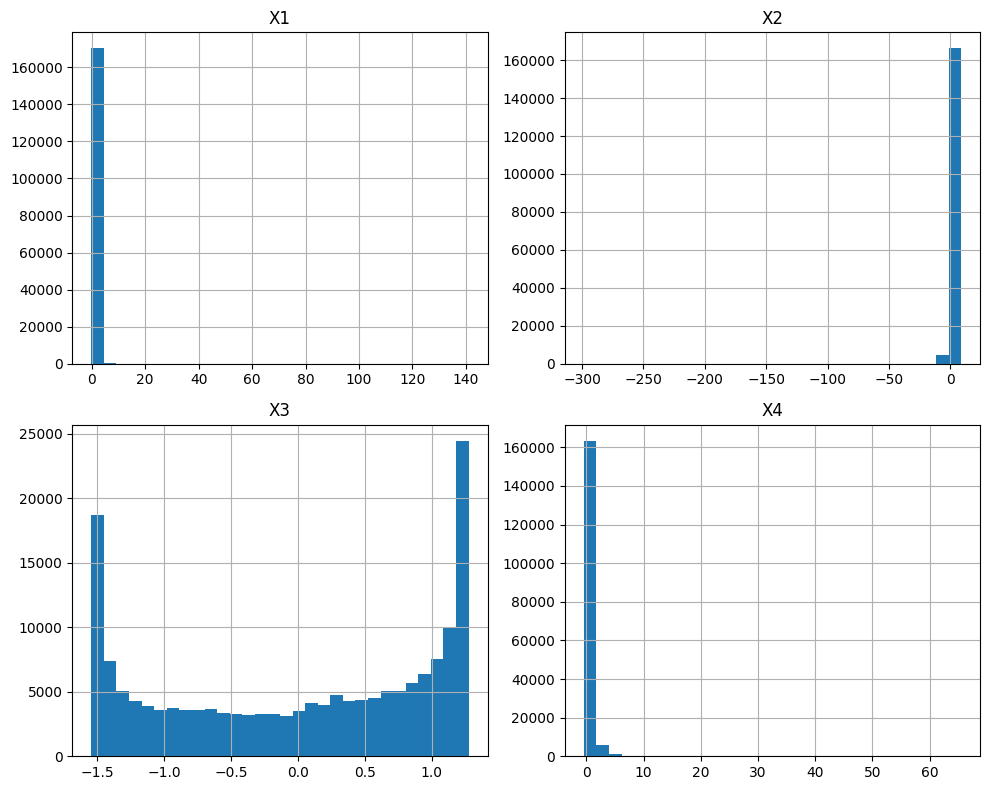

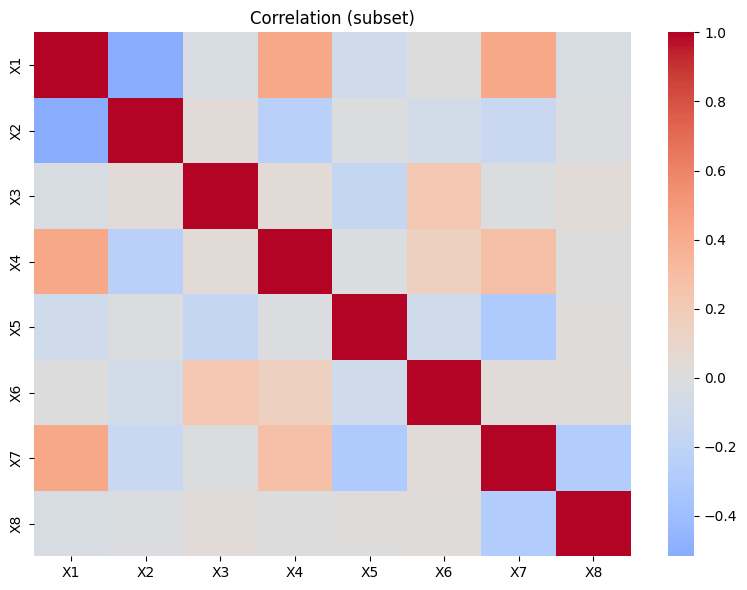

In [3]:
# Quick EDA / sanity checks

# Basic schema
print("Columns:", list(train.columns))
print("Label distribution:\n", train["Label"].value_counts())

# Missing values
print("\nMissing values (train):\n", train.isnull().sum().sort_values(ascending=False).head(20))
print("\nMissing values (test):\n", test.isnull().sum().sort_values(ascending=False).head(20))

# Summary statistics
display(train.describe(include="all").transpose().head(20))

# Pair of histograms for a few numeric columns
numeric_cols = [c for c in train.columns if c != "Label"]
sample_cols = numeric_cols[:4]
train[sample_cols].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

# Correlation heatmap on a small subset (for speed)
sample_corr_cols = numeric_cols[:8]
plt.figure(figsize=(8, 6))
sns.heatmap(train[sample_corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation (subset)")
plt.tight_layout()
plt.show()

In [4]:
# Feature engineering (enhanced)
def compute_row_signals(frame):
    frame = frame.copy()
    all_cols = frame.columns.tolist()

    frame["stat_mean"] = frame[all_cols].mean(axis=1)
    frame["stat_std"] = frame[all_cols].std(axis=1)
    frame["stat_min"] = frame[all_cols].min(axis=1)
    frame["stat_max"] = frame[all_cols].max(axis=1)
    frame["stat_sum"] = frame[all_cols].sum(axis=1)
    frame["stat_abs_sum"] = frame[all_cols].abs().sum(axis=1)
    frame["stat_abs_mean"] = frame[all_cols].abs().mean(axis=1)
    frame["stat_abs_max"] = frame[all_cols].abs().max(axis=1)
    frame["stat_range"] = frame["stat_max"] - frame["stat_min"]
    frame["stat_pos_count"] = (frame[all_cols] > 0).sum(axis=1)
    frame["stat_neg_count"] = (frame[all_cols] < 0).sum(axis=1)
    frame["stat_nonzero"] = (frame[all_cols] != 0).sum(axis=1)
    frame["stat_q25"] = frame[all_cols].quantile(0.25, axis=1)
    frame["stat_q50"] = frame[all_cols].quantile(0.50, axis=1)
    frame["stat_q75"] = frame[all_cols].quantile(0.75, axis=1)
    frame["stat_iqr"] = frame["stat_q75"] - frame["stat_q25"]
    frame["stat_mad"] = (frame[all_cols].sub(frame["stat_q50"], axis=0)).abs().median(axis=1)
    frame["stat_l1_norm"] = frame[all_cols].abs().sum(axis=1)
    frame["stat_l2_norm"] = np.sqrt((frame[all_cols] ** 2).sum(axis=1))
    frame["stat_skew"] = frame[all_cols].skew(axis=1)
    frame["stat_kurt"] = frame[all_cols].kurtosis(axis=1)

    if "Time" in frame.columns:
        frame["time_log1p"] = np.log1p(np.maximum(frame["Time"], 0))
        frame["time_sqrt"] = np.sqrt(np.maximum(frame["Time"], 0))

    return frame

def add_logabs_bundle(frame):
    frame = frame.copy()
    for col in frame.columns:
        if col != "Time":
            frame[f"logabs_{col}"] = np.log1p(np.abs(frame[col]))
    return frame

def add_pairwise_terms(frame, anchor_feats):
    frame = frame.copy()
    usable_feats = [feat for feat in anchor_feats if feat in frame.columns]

    for i in range(len(usable_feats)):
        for j in range(i + 1, len(usable_feats)):
            f1 = usable_feats[i]
            f2 = usable_feats[j]
            frame[f"{f1}_mul_{f2}"] = frame[f1] * frame[f2]
            frame[f"{f1}_diff_{f2}"] = frame[f1] - frame[f2]

    return frame

pairwise_targets = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]

train_matrix = X_base.copy()
test_matrix = X_test_base.copy()

train_matrix = compute_row_signals(train_matrix)
test_matrix = compute_row_signals(test_matrix)

train_matrix = add_logabs_bundle(train_matrix)
test_matrix = add_logabs_bundle(test_matrix)

train_matrix = add_pairwise_terms(train_matrix, pairwise_targets)
test_matrix = add_pairwise_terms(test_matrix, pairwise_targets)

X = train_matrix
X_test = test_matrix

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (170889, 161)
X_test shape: (113918, 161)


In [5]:
# Metric helpers
def pAUC01(y_true, y_prob, sample_weight=None):
    return roc_auc_score(y_true, y_prob, max_fpr=0.01, sample_weight=sample_weight)

def rank01(a):
    return pd.Series(a).rank(method="average").values / len(a)

def cv_oof_preds(model, X, y, sample_weight, n_splits=5, seed=42, name="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(y))
    fold_scores = []
    t0 = time.time()

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        wtr, wva = sample_weight[tr], sample_weight[va]

        model.fit(Xtr, ytr, sample_weight=wtr)
        p = model.predict_proba(Xva)[:, 1]
        oof[va] = p
        fs = pAUC01(yva, p, sample_weight=wva)
        fold_scores.append(fs)
        print(f"[{name}] fold {fold}/5 pAUC@0.01 = {fs:.6f} | elapsed {time.time()-t0:.1f}s")

    score = pAUC01(y, oof, sample_weight=sample_weight)
    print(f"\n[{name}] OOF pAUC@0.01 =", score)
    print(f"[{name}] Fold mean =", np.mean(fold_scores))
    print(f"[{name}] Time (sec) =", round(time.time()-t0, 1))
    print()

    return oof, score

In [ ]:
# Hyperparameter search tuned for extreme imbalance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# pAUC@0.01 scorer
pauc_scorer = make_scorer(
    roc_auc_score,
    greater_is_better=True,
    needs_threshold=True,
    max_fpr=0.01,
)

search_space = {
    "n_estimators": [400, 800, 1200],
    "max_depth": [12, 20, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [False, True],
    "class_weight": [class_weight_map],
}

base_search_estimator = ExtraTreesClassifier(
    min_samples_split=2,
    random_state=2025,
    n_jobs=-1,
)

cv_scheme = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_search_estimator,
    param_grid=search_space,
    scoring=pauc_scorer,
    cv=cv_scheme,
    n_jobs=-1,
    verbose=2,
)

grid.fit(X, y, sample_weight=sample_weights)

print("Best pAUC@0.01:", grid.best_score_)
print("Best params:", grid.best_params_)

# Use tuned params downstream; keep n_jobs and class_weight consistent
tuned_params = {**grid.best_params_, "n_jobs": -1, "class_weight": class_weight_map}


Fitting 4 folds for each of 162 candidates, totalling 648 fits


In [ ]:
# Model setup: seven ExtraTrees seeds
default_params = {
    "n_estimators": 1600,
    "max_depth": 20,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "n_jobs": -1,
    "class_weight": class_weight_map,
}

# If grid search ran, reuse tuned_params; otherwise fall back to defaults
base_params = tuned_params.copy() if "tuned_params" in globals() else default_params

# Distinct seeds to diversify the ensemble
forest_a = ExtraTreesClassifier(**base_params, random_state=42)
forest_b = ExtraTreesClassifier(**base_params, random_state=137)
forest_c = ExtraTreesClassifier(**base_params, random_state=999)
forest_d = ExtraTreesClassifier(**base_params, random_state=2024)
forest_e = ExtraTreesClassifier(**base_params, random_state=31415)
forest_f = ExtraTreesClassifier(**base_params, random_state=2718)
forest_g = ExtraTreesClassifier(**base_params, random_state=777)

In [ ]:
# OOF evaluation
forest_a_oof, _ = cv_oof_preds(forest_a, X, y, sample_weights, name="ET_seed42")
forest_b_oof, _ = cv_oof_preds(forest_b, X, y, sample_weights, name="ET_seed137")
forest_c_oof, _ = cv_oof_preds(forest_c, X, y, sample_weights, name="ET_seed999")
forest_d_oof, _ = cv_oof_preds(forest_d, X, y, sample_weights, name="ET_seed2024")
forest_e_oof, _ = cv_oof_preds(forest_e, X, y, sample_weights, name="ET_seed31415")
forest_f_oof, _ = cv_oof_preds(forest_f, X, y, sample_weights, name="ET_seed2718")
forest_g_oof, _ = cv_oof_preds(forest_g, X, y, sample_weights, name="ET_seed777")

oof_stack = np.vstack([
    forest_a_oof,
    forest_b_oof,
    forest_c_oof,
    forest_d_oof,
    forest_e_oof,
    forest_f_oof,
    forest_g_oof,
])

# probability blend
prob_blend_oof = oof_stack.mean(axis=0)
prob_score = pAUC01(y, prob_blend_oof, sample_weight=sample_weights)

# rank blend
rank_blend_oof = np.mean([rank01(row) for row in oof_stack], axis=0)
rank_score = pAUC01(y, rank_blend_oof, sample_weight=sample_weights)

print("[PROB BLEND] OOF pAUC@0.01 =", prob_score)
print("[RANK BLEND] OOF pAUC@0.01 =", rank_score)

use_rank = rank_score > prob_score
print("\nUsing", "RANK BLEND" if use_rank else "PROBABILITY BLEND", "for final submission")

In [ ]:
# Train full models
t1 = time.time()

forest_a.fit(X, y, sample_weight=sample_weights)
forest_b.fit(X, y, sample_weight=sample_weights)
forest_c.fit(X, y, sample_weight=sample_weights)
forest_d.fit(X, y, sample_weight=sample_weights)
forest_e.fit(X, y, sample_weight=sample_weights)
forest_f.fit(X, y, sample_weight=sample_weights)
forest_g.fit(X, y, sample_weight=sample_weights)

pred_a = forest_a.predict_proba(X_test)[:, 1]
pred_b = forest_b.predict_proba(X_test)[:, 1]
pred_c = forest_c.predict_proba(X_test)[:, 1]
pred_d = forest_d.predict_proba(X_test)[:, 1]
pred_e = forest_e.predict_proba(X_test)[:, 1]
pred_f = forest_f.predict_proba(X_test)[:, 1]
pred_g = forest_g.predict_proba(X_test)[:, 1]

pred_stack = np.vstack([pred_a, pred_b, pred_c, pred_d, pred_e, pred_f, pred_g])

if use_rank:
    test_pred = np.mean([rank01(row) for row in pred_stack], axis=0)
else:
    test_pred = pred_stack.mean(axis=0)

print("Full fit time (sec) =", round(time.time()-t1, 1))

In [ ]:
# Save submission
sub = pd.DataFrame({
    "id": test_ids,
    "Label": np.clip(test_pred, 0, 1),
})

out_path = Path.cwd() / "submission_trees.csv"
sub.to_csv(out_path, index=False)

print("\nSaved", out_path)
print(sub.head())